Shape: (40000, 20)
Columns:
 Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Anomaly Scores',
       'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level',
       'User Information', 'Device Information', 'Network Segment',
       'Geo-location Data', 'Log Source'],
      dtype='object')
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64
Unique classes: 3

Converted to binary classification:
Attack Type
0    26572
1    13428
Name: count, dtype: int64
Dropping high-cardinality columns: ['Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Packet Length', 'Payload Data', 'Anomaly Scores', 'User Information', 'Device Information', 'Geo-location Data']
Numerical: 0 Categorical: 8

Training Logistic Regression...


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Training Decision Tree...

Training KNN...

Training Random Forest...

Training Gradient Boosting...


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Final Results:
                  Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.664250   0.441228  0.664250  0.530243
1        Decision Tree  0.652875   0.540477  0.652875  0.538776
2                  KNN  0.588500   0.547892  0.588500  0.560614
3        Random Forest  0.636750   0.546050  0.636750  0.550937
4    Gradient Boosting  0.664250   0.441228  0.664250  0.530243


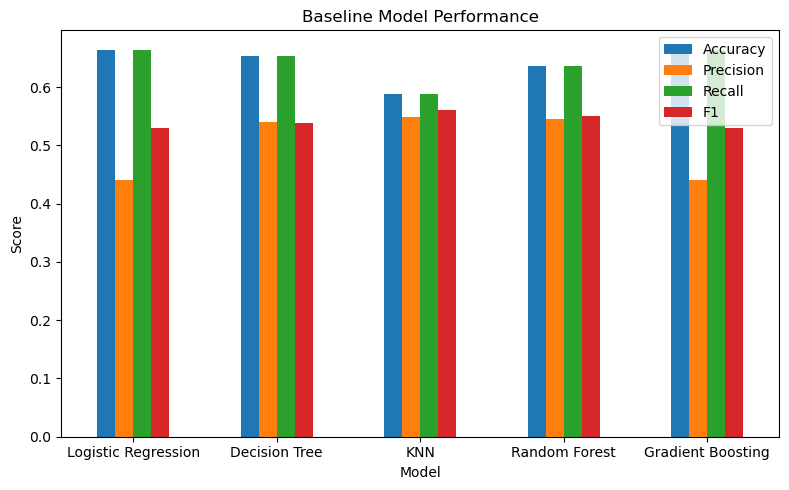

In [14]:

# RQ1: Baseline Performance 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


# 1.LOAD DATASET


df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')

print("Shape:", df.shape)
print("Columns:\n", df.columns)


# 2.TARGET


target = 'Attack Type'   # 🔴 change if needed


# 3. DROP USELESS COLUMNS


drop_cols = ['Timestamp', 'Source IP', 'Destination IP', 'Session ID']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])


# 4.HANDLE MISSING

df = df.dropna()

# 5.SPLIT DATA

X = df.drop(columns=[target])
y = df[target]

print(y.value_counts())
print("Unique classes:", y.nunique())



top_class = y.value_counts().index[0]

y = (y == top_class).astype(int)

print("\nConverted to binary classification:")
print(y.value_counts())
#print("\nTarget Distribution:\n", y.value_counts())

threshold = 50

high_card_cols = [col for col in X.columns if X[col].nunique() > threshold]

print("Dropping high-cardinality columns:", high_card_cols)

X = X.drop(columns=high_card_cols)


# 7.RE-CALCULATE COLUMN TYPES 


num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", len(num_cols), "Categorical:", len(cat_cols))


# 8.PREPROCESSOR 

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', encoder, cat_cols)
])


# 9.TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 10. MODELS
models = {
    "Logistic Regression": Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=2000))
    ]),
    
    "Decision Tree": Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=10))
    ]),
    
    "KNN": Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Random Forest": Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42 ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier()) ])
}

# 11. TRAIN & EVALUATE

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])


# 12. RESULTS

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\nFinal Results:\n", df_results)

df_results.to_csv("RQ1_table.csv", index=False)


# 13. PLOT

df_results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("RQ1_figure.pdf")
plt.show()